# 3T Noise Augmentation Visualization (Training Pipeline Flow)

This notebook follows the same data loading and preprocessing flow as training:
- Uses `create_nifti_patch_dataloader` from `src/Network/NiftiPatchDataset.py`.
- Builds two loaders with identical settings:
  - original batch (no noise augmentation),
  - noisy batch (with exaggerated non-vascular augmentation).

Then it shows:
1. Visual comparison of slices (original vs noisy vs delta).
2. PDF plots from the full batch values (no mask filtering), original vs noisy.
        


In [4]:
from __future__ import annotations

from pathlib import Path
import csv
import inspect
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

import Network.NiftiPatchDataset as npd
importlib.reload(npd)
create_nifti_patch_dataloader = npd.create_nifti_patch_dataloader

np.random.seed(42)
        


## Configuration

- Uses training dataloader flow (`create_nifti_patch_dataloader`).
- Builds two loaders: original (no noise) and noisy (with augmentation).
- PDF can be computed on `masked`, `nonmasked`, or `all` voxels.
- Phase PDF can be forced to fixed range `[-1,1]` for direct comparability.
- Also plots the *noise function actually sampled* by the augmentation.


In [27]:
BASE_CSV = repo_root / "data/paired_dataset/train_random_1.csv"
MASKS_ROOT = repo_root / "data/paired_dataset/cow_segmentation"
FIT_SUMMARY_CSV = repo_root / "output/noise_pdf/nonvascular_noise_fit_summary.csv"

TMP_DIR = repo_root / "output/noise_pdf"
TMP_DIR.mkdir(parents=True, exist_ok=True)
CSV_WITH_MASK = TMP_DIR / "train_random_1_with_masks.csv"

# Data loader params (aligned with training flow).
PATCH_SIZE = 48
RES_INCREASE = 1
BATCH_SIZE = 2
SAMPLES_PER_VOLUME = 1
NUM_WORKERS = 0
SEED = 42

# Randomization controls from training flow.
RANDOM_TIME_FRAME = True
RANDOM_PATCH_SAMPLING = True
ROTATION_PROB = 0.0

# PDF settings.
PDF_REGION_MODE = "nonmasked"  # "masked" | "nonmasked" | "all"
N_PDF_BATCHES = 8
PDF_BINS = 180
PHASE_PDF_FIXED_RANGE = (-1.0, 1.0)
MAG_PDF_FIXED_RANGE = None  # e.g. (0.0, 1.0)

# Preferred exaggerated profile (hat distribution, no CSV override).
# NOISE_CFG = {
#     "noise_aug_prob": 1.0,
#     "noise_aug_fit_summary_csv": "",
#     "noise_aug_phase_dist": "hat",
#     "noise_aug_mag_dist": "hat",

#     # Forma más meseta
#     "noise_aug_hat_mix": 0.96,
#     "noise_aug_phase_shape": 2.5,
#     "noise_aug_mag_shape": 1.8,
#     "noise_aug_exaggerated_side_expand": 1.8,
#     "noise_aug_exaggerated_edge_boost": 0.45,
#     "noise_aug_exaggerated_edge_power": 1.7,

#     # Recuperar amplitud
#     "noise_aug_phase_scale": 0.065,
#     "noise_aug_mag_scale": 0.04,
#     "noise_aug_range_mult": 1.15,
#     "noise_aug_level_min": 0.95,
#     "noise_aug_level_max": 1.7,

#     "noise_aug_apply_mag": True,
#     "noise_aug_clip_mag": True,
# }



NOISE_CFG = {
    "noise_aug_prob": 1.0,
    "noise_aug_fit_summary_csv": str(FIT_SUMMARY_CSV),

    # forma "meseta" (sin irse a U extrema)
    "noise_aug_exaggerated_side_expand": 1.8,
    "noise_aug_exaggerated_edge_boost": 0.30,
    "noise_aug_exaggerated_edge_power": 1.5,

    # amplitud (sin perder fuerza)
    "noise_aug_phase_scale": 0.06,
    "noise_aug_mag_scale": 0.04,
    "noise_aug_range_mult": 1.5,
    "noise_aug_level_min": 1.0,
    "noise_aug_level_max": 2.2,

    "noise_aug_apply_mag": True,
    "noise_aug_clip_mag": False,
}


print(f"BASE_CSV             : {BASE_CSV}")
print(f"CSV_WITH_MASK        : {CSV_WITH_MASK}")
print(f"FIT_SUMMARY_CSV      : {FIT_SUMMARY_CSV}")
print(f"PDF region mode      : {PDF_REGION_MODE}")
print(f"N_PDF_BATCHES        : {N_PDF_BATCHES}")
print(f"PHASE_PDF_FIXED_RANGE: {PHASE_PDF_FIXED_RANGE}")
print(f"Noise cfg            : {NOISE_CFG}")


BASE_CSV             : /Users/alejo/Documents/Internship/NeuroFlow/data/paired_dataset/train_random_1.csv
CSV_WITH_MASK        : /Users/alejo/Documents/Internship/NeuroFlow/output/noise_pdf/train_random_1_with_masks.csv
FIT_SUMMARY_CSV      : /Users/alejo/Documents/Internship/NeuroFlow/output/noise_pdf/nonvascular_noise_fit_summary.csv
PDF region mode      : nonmasked
N_PDF_BATCHES        : 8
PHASE_PDF_FIXED_RANGE: (-1.0, 1.0)
Noise cfg            : {'noise_aug_prob': 1.0, 'noise_aug_fit_summary_csv': '/Users/alejo/Documents/Internship/NeuroFlow/output/noise_pdf/nonvascular_noise_fit_summary.csv', 'noise_aug_exaggerated_side_expand': 1.8, 'noise_aug_exaggerated_edge_boost': 0.3, 'noise_aug_exaggerated_edge_power': 1.5, 'noise_aug_phase_scale': 0.06, 'noise_aug_mag_scale': 0.04, 'noise_aug_range_mult': 1.5, 'noise_aug_level_min': 1.0, 'noise_aug_level_max': 2.2, 'noise_aug_apply_mag': True, 'noise_aug_clip_mag': False}


In [28]:
def _fill_mask_column(input_csv: Path, output_csv: Path, masks_root: Path) -> Path:
    rows = []
    with input_csv.open("r", newline="") as f:
        reader = csv.DictReader(f)
        fieldnames = list(reader.fieldnames or [])
        if "mask" not in fieldnames:
            fieldnames.append("mask")

        for row in reader:
            lr_u = str(row.get("lr_u", "")).strip()
            patient_id = Path(lr_u).parent.name if lr_u else ""

            mask_value = str(row.get("mask", "")).strip()
            if (not mask_value) and patient_id:
                candidate = masks_root / patient_id / "cow_seg_final.nii.gz"
                row["mask"] = str(candidate)
            rows.append(row)

    with output_csv.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return output_csv


def build_loader(csv_path: Path, with_noise: bool):
    kwargs = dict(
        csv_path=str(csv_path),
        patch_size=PATCH_SIZE,
        res_increase=RES_INCREASE,
        batch_size=BATCH_SIZE,
        samples_per_volume=SAMPLES_PER_VOLUME,
        shuffle=False,
        augment=True,
        include_hr_mag=False,
        cache_dataset=False,
        cache_eager=True,
        random_time_frame=RANDOM_TIME_FRAME,
        random_patch_sampling=RANDOM_PATCH_SAMPLING,
        rotation_prob=ROTATION_PROB,
        num_workers=NUM_WORKERS,
        mag_scale=4095.0,
        mag_norm_mode="monai_minmax",
        mask_threshold=0.5,
        raw_phase_input=True,
        invert_uv_sign_on_raw=False,
        raw_center=2048.0,
        raw_scale=2048.0,
        time_axis=-1,
        minimum_coverage=0.0,
        max_sampling_attempts=100,
        allow_empty_fallback=True,
        seed=SEED,
    )

    if with_noise:
        kwargs.update(NOISE_CFG)
    else:
        kwargs.update(
            noise_aug_prob=0.0,
            noise_aug_apply_mag=True,
            noise_aug_clip_mag=False,
        )

    sig = inspect.signature(create_nifti_patch_dataloader)
    supported = set(sig.parameters.keys())
    filtered_kwargs = {k: v for k, v in kwargs.items() if k in supported}
    dropped = [k for k in kwargs.keys() if k not in supported]

    if dropped:
        print(f"[WARN] create_nifti_patch_dataloader in current kernel does not support: {dropped}")
        print("[WARN] Restart kernel and run from first cell to load latest src/Network/NiftiPatchDataset.py")

    return create_nifti_patch_dataloader(**filtered_kwargs)


def unpack_batch(batch):
    # Dataset order:
    # u,v,w,u_mag,v_mag,w_mag,u_hr,v_hr,w_hr,venc,mask
    u, v, w, u_mag, v_mag, w_mag, *_rest = batch
    venc = _rest[-2]
    mask = _rest[-1]

    out = {
        "phase": np.concatenate([u.numpy(), v.numpy(), w.numpy()], axis=1),  # [B,3,X,Y,Z]
        "mag": np.concatenate([u_mag.numpy(), v_mag.numpy(), w_mag.numpy()], axis=1),
        "venc": venc.numpy(),
        "mask": mask.numpy(),
    }
    return out


def _align_mask_to_lr(mask_3d: np.ndarray, target_shape: tuple[int, int, int]) -> np.ndarray:
    if tuple(mask_3d.shape) == tuple(target_shape):
        return mask_3d

    sx, sy, sz = mask_3d.shape
    tx, ty, tz = target_shape
    fx = sx // tx if tx > 0 else 0
    fy = sy // ty if ty > 0 else 0
    fz = sz // tz if tz > 0 else 0

    if (
        fx > 0
        and fy > 0
        and fz > 0
        and sx == tx * fx
        and sy == ty * fy
        and sz == tz * fz
    ):
        return mask_3d.reshape(tx, fx, ty, fy, tz, fz).max(axis=(1, 3, 5))

    ix = np.clip(np.round(np.linspace(0, sx - 1, tx)).astype(np.int64), 0, sx - 1)
    iy = np.clip(np.round(np.linspace(0, sy - 1, ty)).astype(np.int64), 0, sy - 1)
    iz = np.clip(np.round(np.linspace(0, sz - 1, tz)).astype(np.int64), 0, sz - 1)
    return mask_3d[np.ix_(ix, iy, iz)]


def batch_pdf_values(sample: dict, region_mode: str = "all"):
    region_mode = str(region_mode).strip().lower()
    if region_mode not in {"all", "masked", "nonmasked"}:
        raise ValueError(f"Unknown region_mode={region_mode}. Use all/masked/nonmasked.")

    phase = sample["phase"]  # [B,3,X,Y,Z]
    mag = sample["mag"]      # [B,3,X,Y,Z]
    mask_hr = sample["mask"] # [B,*,*,*]

    out = {"Magnitude": [], "Phase Vx": [], "Phase Vy": [], "Phase Vz": []}
    selected_voxels = 0
    total_voxels = 0

    for b in range(int(phase.shape[0])):
        m_lr = _align_mask_to_lr(mask_hr[b], tuple(phase.shape[2:5]))
        total_voxels += int(m_lr.size)

        if region_mode == "all":
            roi = np.ones_like(m_lr, dtype=bool)
        elif region_mode == "masked":
            roi = m_lr >= 0.5
        else:
            roi = m_lr < 0.5

        selected_voxels += int(np.count_nonzero(roi))

        out["Magnitude"].append(mag[b, 0][roi].reshape(-1))
        out["Phase Vx"].append(phase[b, 0][roi].reshape(-1))
        out["Phase Vy"].append(phase[b, 1][roi].reshape(-1))
        out["Phase Vz"].append(phase[b, 2][roi].reshape(-1))

    out = {k: (np.concatenate(v, axis=0) if v else np.array([], dtype=np.float32)) for k, v in out.items()}
    info = {
        "region_mode": region_mode,
        "selected_voxels": int(selected_voxels),
        "total_voxels": int(total_voxels),
        "fraction": float(selected_voxels / max(total_voxels, 1)),
    }
    return out, info


def collect_region_values(loader, region_mode: str, n_batches: int):
    pooled = {"Magnitude": [], "Phase Vx": [], "Phase Vy": [], "Phase Vz": []}
    agg_selected = 0
    agg_total = 0

    it = iter(loader)
    for _ in range(int(max(n_batches, 1))):
        try:
            batch = next(it)
        except StopIteration:
            it = iter(loader)
            batch = next(it)

        sample = unpack_batch(batch)
        vals, info = batch_pdf_values(sample, region_mode=region_mode)
        for ch in pooled:
            if vals[ch].size:
                pooled[ch].append(vals[ch])
        agg_selected += int(info["selected_voxels"])
        agg_total += int(info["total_voxels"])

    pooled = {k: (np.concatenate(v, axis=0) if v else np.array([], dtype=np.float32)) for k, v in pooled.items()}
    return pooled, {
        "region_mode": region_mode,
        "selected_voxels": agg_selected,
        "total_voxels": agg_total,
        "fraction": float(agg_selected / max(agg_total, 1)),
        "n_batches": int(max(n_batches, 1)),
    }


def build_noise_augmenter_from_cfg(noise_cfg: dict):
    if not hasattr(npd, "_AddNonvascularNoiseAugd"):
        raise RuntimeError("_AddNonvascularNoiseAugd is not available in loaded module.")
    cls = npd._AddNonvascularNoiseAugd
    sig = inspect.signature(cls.__init__)
    supported = set(sig.parameters.keys())

    kwargs = {}
    for k, v in noise_cfg.items():
        k2 = k.replace("noise_aug_", "", 1) if k.startswith("noise_aug_") else k
        if k2 in supported:
            kwargs[k2] = v
    if "prob" not in kwargs:
        kwargs["prob"] = 1.0

    return cls(**kwargs)


In [29]:
csv_used = _fill_mask_column(BASE_CSV, CSV_WITH_MASK, MASKS_ROOT)

loader_orig = build_loader(csv_used, with_noise=False)
loader_noisy = build_loader(csv_used, with_noise=True)


        


NIfTI dataset /Users/alejo/Documents/Internship/NeuroFlow/output/noise_pdf/train_random_1_with_masks.csv: 6 volume(s), 6 patch samples
[INFO] Noise augmentation using precomputed best-fit families from CSV: Magnitude:skew_normal(shape=3.673), Phase Vx:generalized_normal(shape=1.566), Phase Vy:generalized_normal(shape=1.574), Phase Vz:generalized_normal(shape=1.56)
NIfTI dataset /Users/alejo/Documents/Internship/NeuroFlow/output/noise_pdf/train_random_1_with_masks.csv: 6 volume(s), 6 patch samples


In [41]:
batch_orig = next(iter(loader_orig))
batch_noisy = next(iter(loader_noisy))

orig = unpack_batch(batch_orig)
noisy = unpack_batch(batch_noisy)

print("Original venc:", orig["venc"])
print("Noisy venc   :", noisy["venc"])
print("Phase shape  :", orig["phase"].shape)
print("Mag shape    :", orig["mag"].shape)

Original venc: [0.9 0.9]
Noisy venc   : [0.9 0.9]
Phase shape  : (2, 3, 48, 48, 48)
Mag shape    : (2, 3, 48, 48, 48)


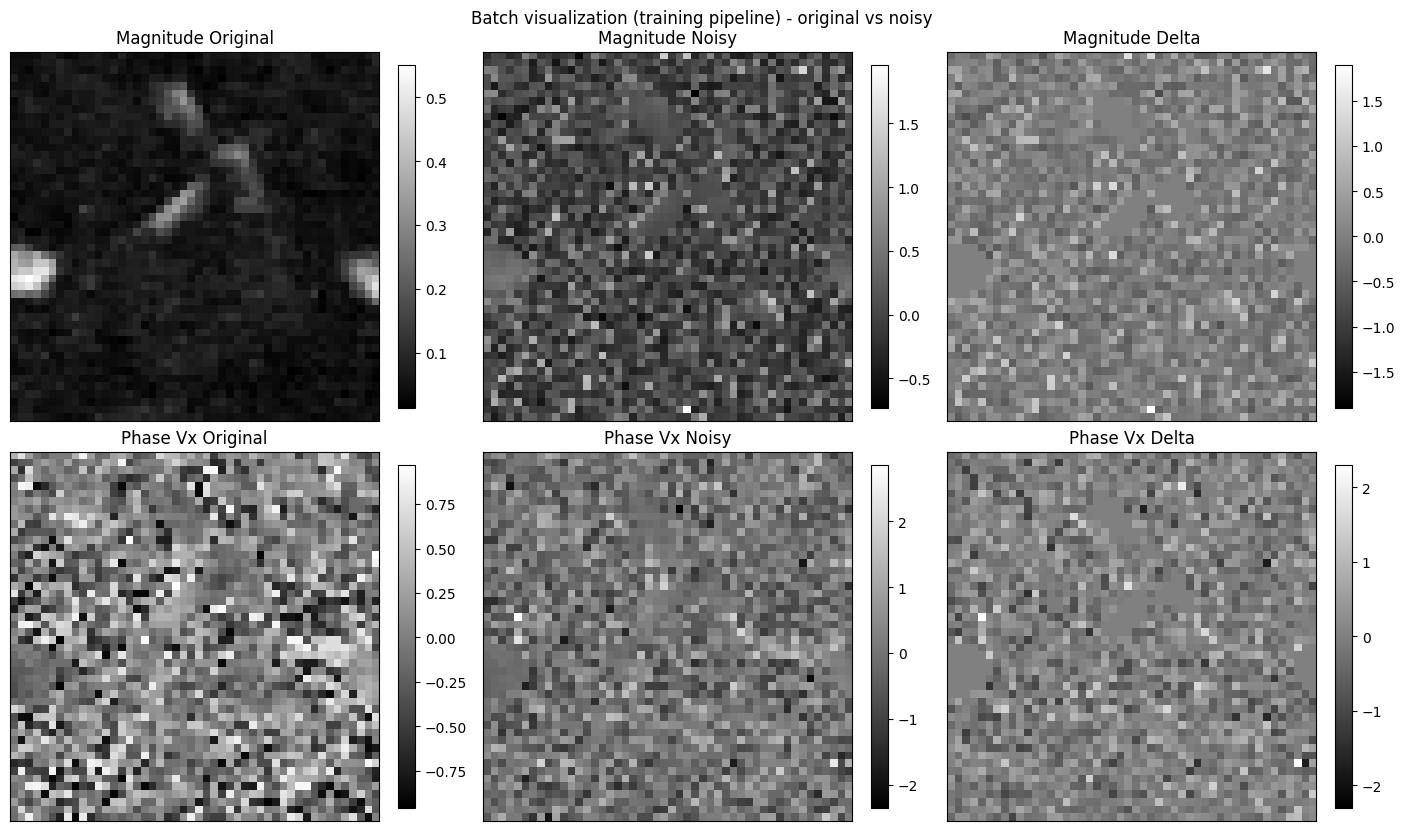

In [42]:
# Slice visualization (single sample from batch, no mask filtering)
b = 1
z = orig["mag"].shape[-1] // 2

orig_mag = orig["mag"][b, 0, :, :, z]
noisy_mag = noisy["mag"][b, 0, :, :, z]
delta_mag = noisy_mag - orig_mag

orig_vx = orig["phase"][b, 0, :, :, z]
noisy_vx = noisy["phase"][b, 0, :, :, z]
delta_vx = noisy_vx - orig_vx

fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

im0 = axs[0, 0].imshow(orig_mag.T, cmap="gray", origin="lower")
axs[0, 0].set_title("Magnitude Original")
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046)

im1 = axs[0, 1].imshow(noisy_mag.T, cmap="gray", origin="lower")
axs[0, 1].set_title("Magnitude Noisy")
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046)

m_lim = np.max(np.abs(delta_mag)) + 1e-8
im2 = axs[0, 2].imshow(delta_mag.T, cmap="gray", vmin=-m_lim, vmax=m_lim, origin="lower")
axs[0, 2].set_title("Magnitude Delta")
fig.colorbar(im2, ax=axs[0, 2], fraction=0.046)

im3 = axs[1, 0].imshow(orig_vx.T, cmap="gray", origin="lower")
axs[1, 0].set_title("Phase Vx Original")
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046)

im4 = axs[1, 1].imshow(noisy_vx.T, cmap="gray", origin="lower")
axs[1, 1].set_title("Phase Vx Noisy")
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046)

v_lim = np.max(np.abs(delta_vx)) + 1e-8
im5 = axs[1, 2].imshow(delta_vx.T, cmap="gray", vmin=-v_lim, vmax=v_lim, origin="lower")
axs[1, 2].set_title("Phase Vx Delta")
fig.colorbar(im5, ax=axs[1, 2], fraction=0.046)

for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Batch visualization (training pipeline) - original vs noisy", y=1.02)
plt.show()
        


[INFO] Noise augmentation using precomputed best-fit families from CSV: Magnitude:skew_normal(shape=3.673), Phase Vx:generalized_normal(shape=1.566), Phase Vy:generalized_normal(shape=1.574), Phase Vz:generalized_normal(shape=1.56)
Augmenter class: _AddNonvascularNoiseAugd
phase_dist: student_t shape: 3.0 scale: 0.06
mag_dist  : skew_normal shape: 4.0 scale: 0.04
hat_mix   : 0.7
side_expand: 1.8
edge_boost : 0.3
edge_power : 1.5
level range: (1.0, 2.2)
range mult : 2.0


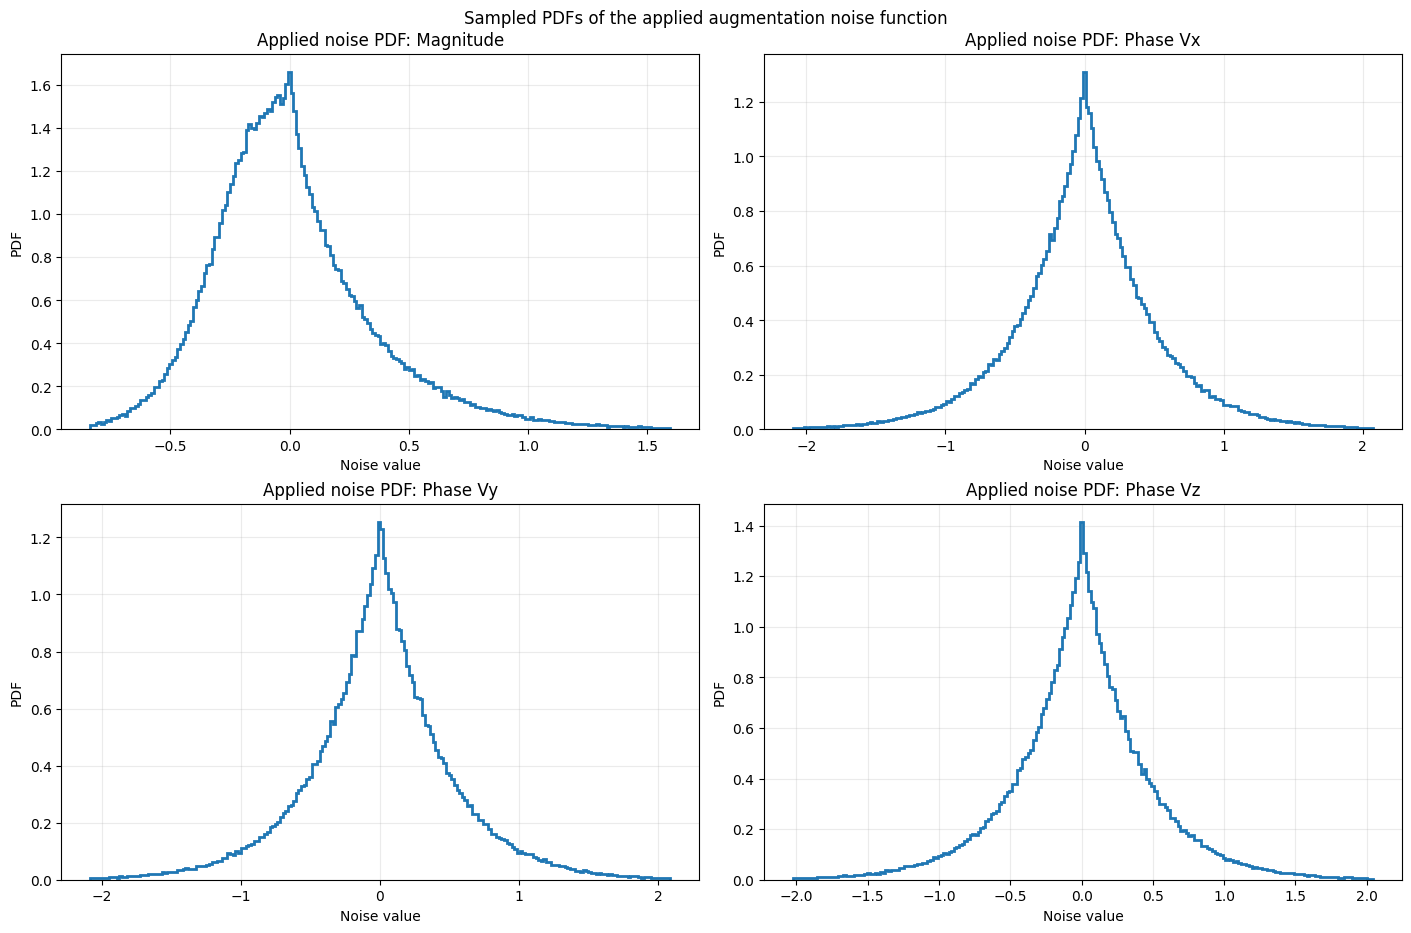

In [32]:
aug = build_noise_augmenter_from_cfg(NOISE_CFG)

print("Augmenter class:", type(aug).__name__)
print("phase_dist:", aug.phase_dist, "shape:", aug.phase_shape, "scale:", aug.phase_scale)
print("mag_dist  :", aug.mag_dist, "shape:", aug.mag_shape, "scale:", aug.mag_scale)
print("hat_mix   :", aug.hat_mix)
print("side_expand:", aug.exaggerated_side_expand)
print("edge_boost :", aug.exaggerated_edge_boost)
print("edge_power :", aug.exaggerated_edge_power)
print("level range:", (aug.level_min, aug.level_max))
print("range mult :", aug.range_multiplier)


def sample_noise_pdf(aug, channel_name: str, repeats: int = 80, n_per_repeat: int = 4096):
    chunks = []
    for _ in range(repeats):
        if channel_name == "Magnitude":
            x = aug._sample_noise(
                shape=(n_per_repeat,),
                dist=aug.mag_dist,
                scale=aug.mag_scale,
                shape_param=aug.mag_shape,
                channel_name="Magnitude",
            )
        else:
            x = aug._sample_noise(
                shape=(n_per_repeat,),
                dist=aug.phase_dist,
                scale=aug.phase_scale,
                shape_param=aug.phase_shape,
                channel_name=channel_name,
            )
        chunks.append(np.asarray(x, dtype=np.float64).reshape(-1))
    return np.concatenate(chunks, axis=0)

noise_samples = {
    "Magnitude": sample_noise_pdf(aug, "Magnitude"),
    "Phase Vx": sample_noise_pdf(aug, "Phase Vx"),
    "Phase Vy": sample_noise_pdf(aug, "Phase Vy"),
    "Phase Vz": sample_noise_pdf(aug, "Phase Vz"),
}

fig, axs = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, ch in zip(axs.ravel(), ["Magnitude", "Phase Vx", "Phase Vy", "Phase Vz"]):
    x = noise_samples[ch]
    lo, hi = float(np.percentile(x, 0.2)), float(np.percentile(x, 99.8))
    ax.hist(x, bins=220, range=(lo, hi), density=True, histtype="step", linewidth=2.0)
    ax.set_title(f"Applied noise PDF: {ch}")
    ax.set_xlabel("Noise value")
    ax.set_ylabel("PDF")
    ax.grid(alpha=0.25)

fig.suptitle("Sampled PDFs of the applied augmentation noise function", y=1.02)
plt.show()


Original region info: {'region_mode': 'nonmasked', 'selected_voxels': 1689154, 'total_voxels': 1769472, 'fraction': 0.9546090585214121, 'n_batches': 8}
Noisy region info   : {'region_mode': 'nonmasked', 'selected_voxels': 1689154, 'total_voxels': 1769472, 'fraction': 0.9546090585214121, 'n_batches': 8}


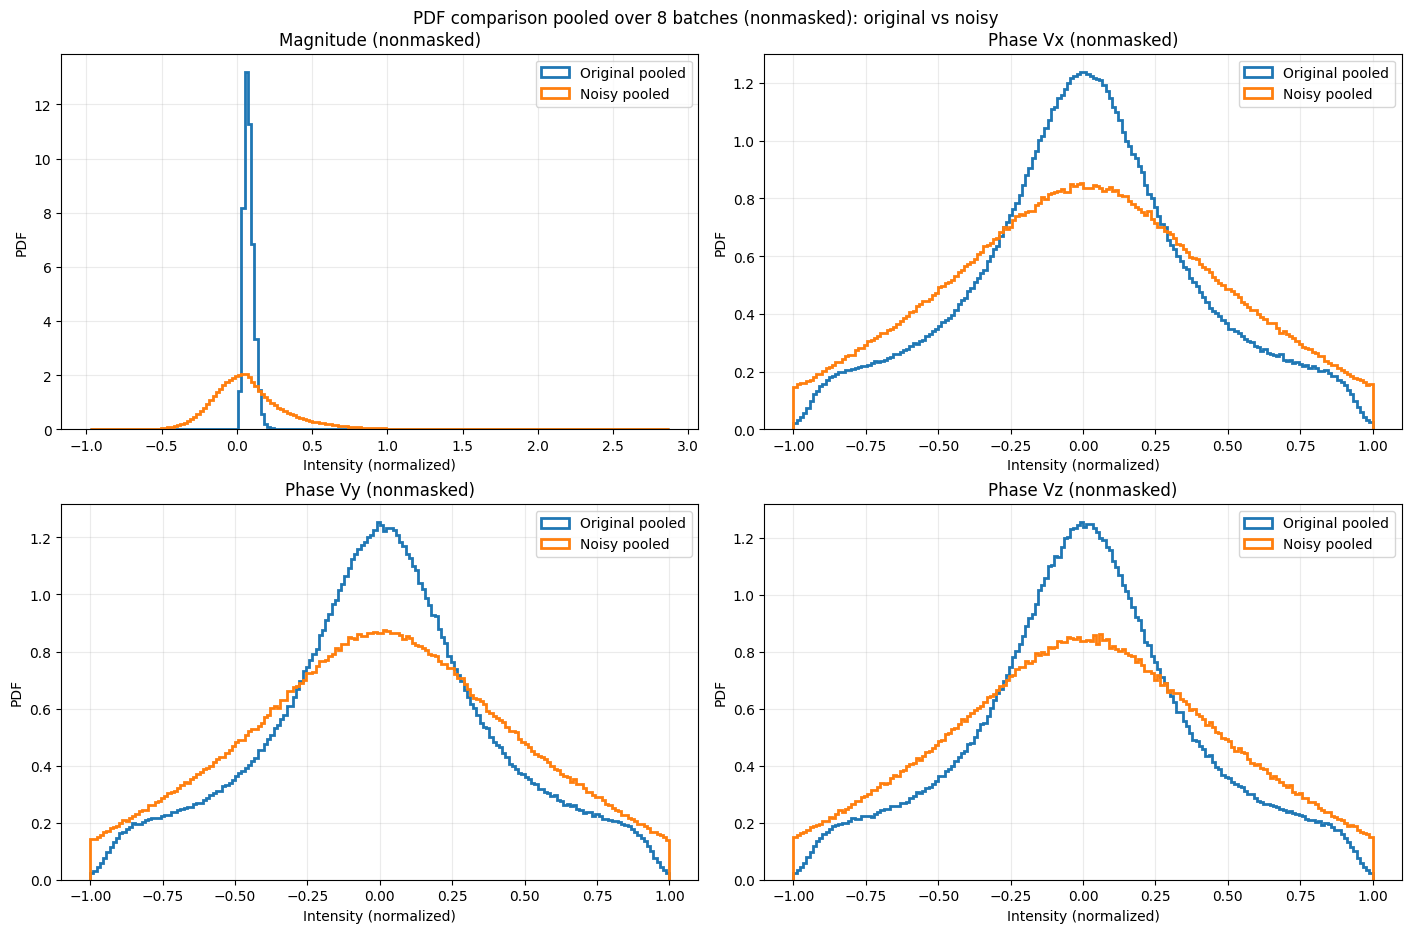

In [33]:
# PDF comparison on pooled batch values (selected region)
vals_orig, info_orig = collect_region_values(loader_orig, PDF_REGION_MODE, n_batches=N_PDF_BATCHES)
vals_noisy, info_noisy = collect_region_values(loader_noisy, PDF_REGION_MODE, n_batches=N_PDF_BATCHES)

print("Original region info:", info_orig)
print("Noisy region info   :", info_noisy)

fig, axs = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
channels = ["Magnitude", "Phase Vx", "Phase Vy", "Phase Vz"]

for ax, ch in zip(axs.ravel(), channels):
    x0 = vals_orig[ch]
    x1 = vals_noisy[ch]

    if x0.size == 0 or x1.size == 0:
        ax.set_title(f"{ch} ({PDF_REGION_MODE}) - no data")
        ax.set_xlabel("Intensity (normalized)")
        ax.set_ylabel("PDF")
        ax.grid(alpha=0.25)
        continue

    # Fixed range for phase improves visual comparability with training-normalized support.
    if ch.startswith("Phase") and PHASE_PDF_FIXED_RANGE is not None:
        lo, hi = map(float, PHASE_PDF_FIXED_RANGE)
    elif ch == "Magnitude" and MAG_PDF_FIXED_RANGE is not None:
        lo, hi = map(float, MAG_PDF_FIXED_RANGE)
    else:
        lo = float(min(np.min(x0), np.min(x1)))
        hi = float(max(np.max(x0), np.max(x1)))

    if hi <= lo:
        hi = lo + 1e-6

    ax.hist(x0, bins=PDF_BINS, range=(lo, hi), density=True, histtype="step", linewidth=2.0, label="Original pooled")
    ax.hist(x1, bins=PDF_BINS, range=(lo, hi), density=True, histtype="step", linewidth=2.0, label="Noisy pooled")

    ax.set_title(f"{ch} ({PDF_REGION_MODE})")
    ax.set_xlabel("Intensity (normalized)")
    ax.set_ylabel("PDF")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle(
    f"PDF comparison pooled over {N_PDF_BATCHES} batches ({PDF_REGION_MODE}): original vs noisy",
    y=1.02,
)
plt.show()


In [35]:
# Quick numeric summary (selected region, pooled)
for ch in ["Magnitude", "Phase Vx", "Phase Vy", "Phase Vz"]:
    x0 = vals_orig[ch]
    x1 = vals_noisy[ch]
    if x0.size == 0 or x1.size == 0:
        print(f"{ch:10s} | no data in region={PDF_REGION_MODE}")
        continue
    print(
        f"{ch:10s} | mean {x0.mean(): .5f} -> {x1.mean(): .5f} | std {x0.std(): .5f} -> {x1.std(): .5f}"
    )


Magnitude  | mean  0.07910 ->  0.08485 | std  0.03450 ->  0.25882
Phase Vx   | mean  0.00391 ->  0.00397 | std  0.39108 ->  0.56320
Phase Vy   | mean  0.00309 ->  0.00272 | std  0.39093 ->  0.55731
Phase Vz   | mean  0.00219 ->  0.00239 | std  0.38986 ->  0.57240


## Same Image at Multiple Noise Levels

This section keeps one fixed base sample and applies augmentation with different fixed levels
(`noise_aug_level_min = noise_aug_level_max = level`) to visualize how random data augmentation scale changes.


In [36]:
SWEEP_SAMPLE_INDEX = 0
NOISE_LEVELS = [0.4, 0.7, 1.0, 1.3, 1.6, 2.0]
SWEEP_REGION_MODE = PDF_REGION_MODE
SWEEP_SEED = 123


def make_single_sample_from_unpacked(unpacked: dict, sample_idx: int) -> dict:
    phase = np.asarray(unpacked["phase"][sample_idx], dtype=np.float32)  # [3,X,Y,Z]
    mag = np.asarray(unpacked["mag"][sample_idx], dtype=np.float32)      # [3,X,Y,Z]
    mask_hr = np.asarray(unpacked["mask"][sample_idx], dtype=np.float32)
    mask_lr = _align_mask_to_lr(mask_hr, tuple(phase.shape[1:4])).astype(np.float32)
    return {"lr_vel": phase.copy(), "lr_mag": mag.copy(), "mask": mask_lr.copy()}


def apply_level_to_sample(base_sample: dict, level: float, seed: int = 0) -> dict:
    cfg = dict(NOISE_CFG)
    cfg["noise_aug_prob"] = 1.0
    cfg["noise_aug_level_min"] = float(level)
    cfg["noise_aug_level_max"] = float(level)

    aug = build_noise_augmenter_from_cfg(cfg)
    if hasattr(aug, "set_random_state"):
        aug.set_random_state(seed=int(seed))

    out = aug(dict(base_sample))
    return {
        "lr_vel": np.asarray(out["lr_vel"], dtype=np.float32),
        "lr_mag": np.asarray(out["lr_mag"], dtype=np.float32),
        "mask": np.asarray(out["mask"], dtype=np.float32),
    }


def sample_to_pdf_values(sample_dict: dict, region_mode: str):
    wrapped = {
        "phase": sample_dict["lr_vel"][None, ...],
        "mag": sample_dict["lr_mag"][None, ...],
        "mask": sample_dict["mask"][None, ...],
    }
    return batch_pdf_values(wrapped, region_mode=region_mode)


base_single = make_single_sample_from_unpacked(orig, SWEEP_SAMPLE_INDEX)
sweep_samples = {"original": base_single}
for lvl in NOISE_LEVELS:
    sweep_samples[f"level={lvl:.2f}"] = apply_level_to_sample(base_single, level=lvl, seed=SWEEP_SEED)

print("Built sweep samples:", list(sweep_samples.keys()))


[INFO] Noise augmentation using precomputed best-fit families from CSV: Magnitude:skew_normal(shape=3.673), Phase Vx:generalized_normal(shape=1.566), Phase Vy:generalized_normal(shape=1.574), Phase Vz:generalized_normal(shape=1.56)
[INFO] Noise augmentation using precomputed best-fit families from CSV: Magnitude:skew_normal(shape=3.673), Phase Vx:generalized_normal(shape=1.566), Phase Vy:generalized_normal(shape=1.574), Phase Vz:generalized_normal(shape=1.56)
[INFO] Noise augmentation using precomputed best-fit families from CSV: Magnitude:skew_normal(shape=3.673), Phase Vx:generalized_normal(shape=1.566), Phase Vy:generalized_normal(shape=1.574), Phase Vz:generalized_normal(shape=1.56)
[INFO] Noise augmentation using precomputed best-fit families from CSV: Magnitude:skew_normal(shape=3.673), Phase Vx:generalized_normal(shape=1.566), Phase Vy:generalized_normal(shape=1.574), Phase Vz:generalized_normal(shape=1.56)
[INFO] Noise augmentation using precomputed best-fit families from CSV: 

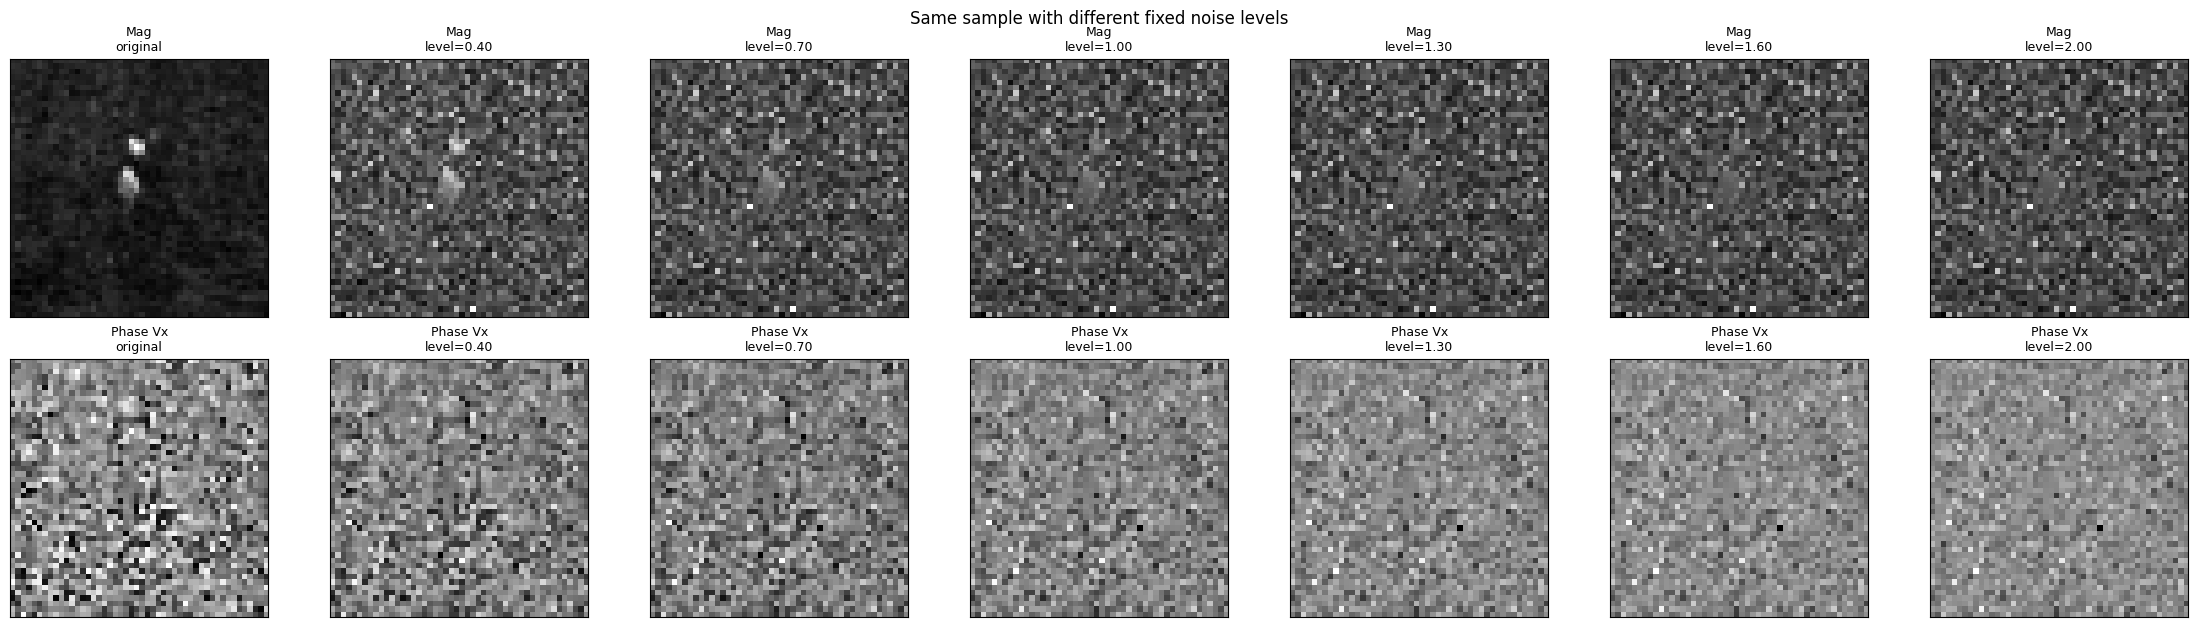

In [37]:
# Visual comparison on exactly the same sample
z = sweep_samples["original"]["lr_mag"].shape[-1] // 2
labels = list(sweep_samples.keys())

fig, axs = plt.subplots(2, len(labels), figsize=(3.2 * len(labels), 6), constrained_layout=True)

for j, label in enumerate(labels):
    s = sweep_samples[label]
    mag = s["lr_mag"][0, :, :, z]
    vx = s["lr_vel"][0, :, :, z]

    axs[0, j].imshow(mag.T, cmap="gray", origin="lower")
    axs[0, j].set_title(f"Mag\n{label}", fontsize=9)
    axs[0, j].set_xticks([])
    axs[0, j].set_yticks([])

    axs[1, j].imshow(vx.T, cmap="gray", origin="lower")
    axs[1, j].set_title(f"Phase Vx\n{label}", fontsize=9)
    axs[1, j].set_xticks([])
    axs[1, j].set_yticks([])

fig.suptitle("Same sample with different fixed noise levels", y=1.02)
plt.show()


Region info (same sample):
original {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}
level=0.40 {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}
level=0.70 {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}
level=1.00 {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}
level=1.30 {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}
level=1.60 {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}
level=2.00 {'region_mode': 'nonmasked', 'selected_voxels': 104844, 'total_voxels': 110592, 'fraction': 0.9480251736111112}


/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/ipykernel_40175/2096661346.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0.0, 0.0, 0.86, 0.95])


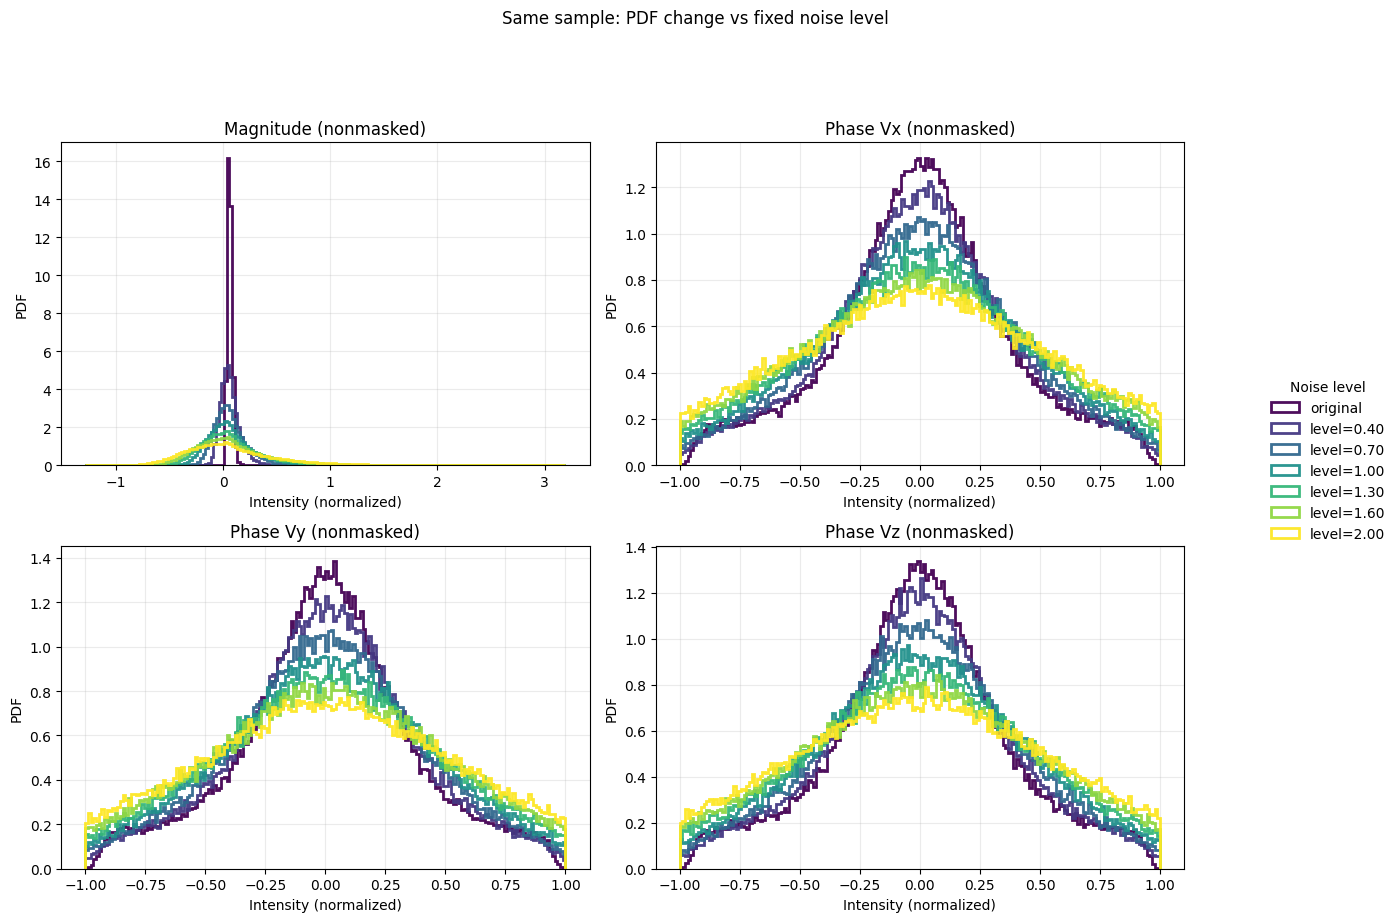

In [38]:
# PDF curves vs noise level on same sample
vals_by_label = {}
info_by_label = {}
for label, s in sweep_samples.items():
    vals, info = sample_to_pdf_values(s, region_mode=SWEEP_REGION_MODE)
    vals_by_label[label] = vals
    info_by_label[label] = info

print("Region info (same sample):")
for k, v in info_by_label.items():
    print(k, v)

fig, axs = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
channels = ["Magnitude", "Phase Vx", "Phase Vy", "Phase Vz"]
colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(labels)))

for ax, ch in zip(axs.ravel(), channels):
    # fixed phase range for easier comparison
    if ch.startswith("Phase") and PHASE_PDF_FIXED_RANGE is not None:
        lo, hi = map(float, PHASE_PDF_FIXED_RANGE)
    elif ch == "Magnitude" and MAG_PDF_FIXED_RANGE is not None:
        lo, hi = map(float, MAG_PDF_FIXED_RANGE)
    else:
        all_vals = [vals_by_label[l][ch] for l in labels if vals_by_label[l][ch].size > 0]
        lo = float(min(np.min(v) for v in all_vals)) if all_vals else -1.0
        hi = float(max(np.max(v) for v in all_vals)) if all_vals else 1.0
    if hi <= lo:
        hi = lo + 1e-6

    for c, label in zip(colors, labels):
        x = vals_by_label[label][ch]
        if x.size == 0:
            continue
        ax.hist(
            x,
            bins=PDF_BINS,
            range=(lo, hi),
            density=True,
            histtype="step",
            linewidth=2.0,
            color=c,
            alpha=0.95,
            label=label,
        )

    ax.set_title(f"{ch} ({SWEEP_REGION_MODE})")
    ax.set_xlabel("Intensity (normalized)")
    ax.set_ylabel("PDF")
    ax.grid(alpha=0.25)

handles, labels_leg = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="center right", title="Noise level", frameon=False)
fig.suptitle("Same sample: PDF change vs fixed noise level", y=1.02)
plt.tight_layout(rect=[0.0, 0.0, 0.86, 0.95])
plt.show()


In [16]:
# Numeric summary of perturbation strength vs level (same sample)
base = sweep_samples["original"]
for label in labels[1:]:
    cur = sweep_samples[label]
    dmag = cur["lr_mag"][0] - base["lr_mag"][0]
    dvx = cur["lr_vel"][0] - base["lr_vel"][0]
    dvy = cur["lr_vel"][1] - base["lr_vel"][1]
    dvz = cur["lr_vel"][2] - base["lr_vel"][2]
    print(
        f"{label:10s} | std(delta_mag)={dmag.std():.5f} | "
        f"std(delta_vx)={dvx.std():.5f} | std(delta_vy)={dvy.std():.5f} | std(delta_vz)={dvz.std():.5f}"
    )


level=0.40 | std(delta_mag)=0.10196 | std(delta_vx)=0.16584 | std(delta_vy)=0.16579 | std(delta_vz)=0.16576
level=0.70 | std(delta_mag)=0.17843 | std(delta_vx)=0.29022 | std(delta_vy)=0.29013 | std(delta_vz)=0.29008
level=1.00 | std(delta_mag)=0.25491 | std(delta_vx)=0.41460 | std(delta_vy)=0.41448 | std(delta_vz)=0.41440
level=1.30 | std(delta_mag)=0.33138 | std(delta_vx)=0.53897 | std(delta_vy)=0.53882 | std(delta_vz)=0.53872
level=1.60 | std(delta_mag)=0.40785 | std(delta_vx)=0.66335 | std(delta_vy)=0.66317 | std(delta_vz)=0.66303
level=2.00 | std(delta_mag)=0.50981 | std(delta_vx)=0.82919 | std(delta_vy)=0.82896 | std(delta_vz)=0.82879
